# 02 — Data Preprocessing & Class Imbalance Handling
**Objective:** Feature engineering → SMOTE oversampling → Save processed data to data/processed/

In [1]:
import sys; sys.path.append('..')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns, warnings
warnings.filterwarnings('ignore')
from src.data_loader import load_data
from src.preprocess import (engineer_features, filter_fraud_types,
    split_features_target, split_train_test, apply_smote)
sns.set_theme(style='whitegrid')
print('Setup OK')

Setup OK


## 1. Load Raw Data

In [2]:

df = load_data(nrows=500_000)
df.head()

✅ Loaded 500,000 rows x 9 cols | RAM: 12.5 MB | Fraud rate: 0.0466%


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.639648,170136.0,160296.359375,0.0,0.0,0,0
1,1,PAYMENT,1864.280029,21249.0,19384.720703,0.0,0.0,0,0
2,1,TRANSFER,181.000000,181.0,0.000000,0.0,0.0,1,0
3,1,CASH_OUT,181.000000,181.0,0.000000,21182.0,0.0,1,0
4,1,PAYMENT,11668.139648,41554.0,29885.859375,0.0,0.0,0,0


## 2. Feature Engineering

Create `errorBalanceOrig` and `errorBalanceDest` — balance discrepancy features
(key EDA insight: fraud transactions often drain the account balance)

In [3]:
df_feat = engineer_features(df)
print('Columns:', df_feat.columns.tolist())
df_feat.head()

Columns: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'errorBalanceOrig', 'errorBalanceDest', 'type_encoded']


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,errorBalanceOrig,errorBalanceDest,type_encoded
0,1,9839.639648,170136.0,160296.359375,0.0,0.0,0,0.0,9839.639648,3
1,1,1864.280029,21249.0,19384.720703,0.0,0.0,0,0.0,1864.280029,3
2,1,181.000000,181.0,0.000000,0.0,0.0,1,0.0,181.000000,4
3,1,181.000000,181.0,0.000000,21182.0,0.0,1,0.0,21363.000000,1
4,1,11668.139648,41554.0,29885.859375,0.0,0.0,0,0.0,11668.139648,3


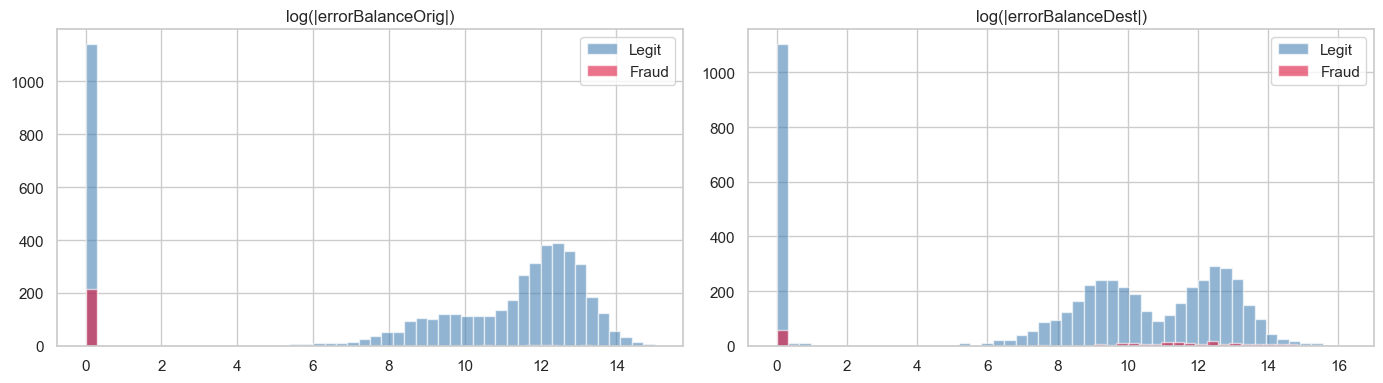

In [4]:
# Check if fraud transactions have higher balance errors than legitimate transactions
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col in zip(axes, ['errorBalanceOrig', 'errorBalanceDest']):
    ax.hist(np.log1p(np.abs(df_feat[df_feat.isFraud==0][col].sample(5000))),
            bins=50, alpha=0.6, label='Legit', color='steelblue')
    ax.hist(np.log1p(np.abs(df_feat[df_feat.isFraud==1][col])),
            bins=50, alpha=0.6, label='Fraud', color='crimson')
    ax.set_title(f'log(|{col}|)'); ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/error_balance_dist.png', dpi=150)
plt.show()

## 3. Filter Transaction Types

EDA insight: Fraud occurs **only** in TRANSFER and CASH_OUT transactions.


In [5]:
df_f = filter_fraud_types(df_feat)
print(f'Fraud rate after filtering: {df_f.isFraud.mean()*100:.3f}%')

✅ After type filtering: 223,046 / 500,000 rows
Fraud rate after filtering: 0.104%


## 4. Train-Test Split (Stratified)

In [6]:
X, y = split_features_target(df_f)
X_train, X_test, y_train, y_test = split_train_test(X, y)
print('Features:', X.columns.tolist())

✅ Train 178,436 (fraud 0.104%) | Test 44,610 (fraud 0.105%)
Features: ['step', 'type_encoded', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'errorBalanceOrig', 'errorBalanceDest']


## 5. SMOTE

> **Important:** Apply SMOTE only on the training set, NOT on the test set!
> Applying it on the test set causes data leakage → artificially inflated results.

✅ After SMOTE: Non-fraud 35,650 | Fraud 17,825 (33.33%)


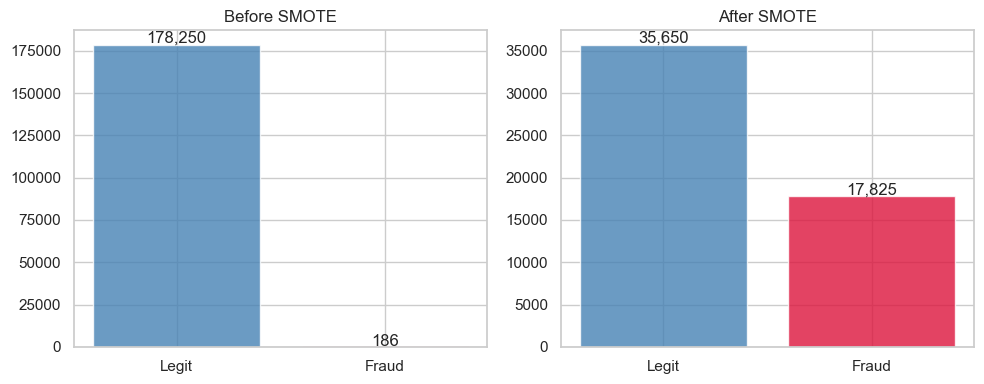

In [9]:
X_res, y_res = apply_smote(X_train, y_train)

# Visualize before vs after
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (y_d, title) in zip(axes,[(y_train,'Before SMOTE'),(y_res,'After SMOTE')]):
    c = pd.Series(y_d).value_counts()
    ax.bar(['Legit','Fraud'], c.values, color=['steelblue','crimson'], alpha=0.8)
    ax.set_title(title)
    for i,v in enumerate(c.values): ax.text(i, v*1.01, f'{v:,}', ha='center')
plt.tight_layout()
plt.savefig('../reports/figures/smote_comparison.png', dpi=150)
plt.show()

## 6. Save Processed Data

In [8]:
import os; os.makedirs('../data/processed', exist_ok=True)
X_res.to_csv('../data/processed/X_train.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv', index=False)
y_res.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)
print('Saved all processed data!')

Saved all processed data!
